In [ ]:
# Run from the repository root so data/, scripts/, dashboard/, outputs/ paths resolve.
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Subjective-Confidence Detector
### Chapter 5 (Study 2): reproduces Section 3.4: the honest-null regression, the low-confidence detector, and the calibration / overconfidence analysis

**Question.** Does pre-probe behaviour predict how *confident* the operator will feel, and does that felt confidence track whether they are actually right?

**Three parts.**
- **A: Regression (honest null).** Predict the continuous 1–7 confidence rating; the result is a near-zero R², reported honestly.
- **B: Low-confidence detector.** Reframe as classification: can we flag an *unsure* operator (rating ≤ 4)? Weakly predictable.
- **C: Calibration.** Does confidence align with correctness, or are operators overconfident?

**Scope.** Parts A & B use the demanding **Sign + Animal** probes (n = 439, 37 operators); Part C and the overt-lapse descriptive use the full task-wide set.

**Data.** `route1…6_ml_ready.csv`.

---

### Packages, and what each is used for
| Package | Used for | Why |
|---|---|---|
| **pandas / numpy** | probe table, feature scaling | standard tabular handling |
| **scikit-learn** | low-confidence detector (**LogisticRegression**), grouped CV, metrics, calibration curve | logistic won the comparison and gives interpretable, well-calibrated coefficients; grouped CV prevents operator leakage |
| **xgboost** | baseline in the detector comparison | benchmarked, not selected |
| **statsmodels** | Part-A regression / variance decomposition | quantifies how little continuous confidence behaviour explains |
| **matplotlib** | PR curve, calibration plot | figures |

### Why these methods
- **Report the null honestly (Part A).** Continuous confidence is ~88% within-person variance and essentially unpredictable from behaviour; the near-zero R² is reported, not hidden.
- **Reframe to the answerable question (Part B).** "Is the operator unsure?" (≤ 4) is the decision-relevant, learnable target.
- **Logistic regression, chosen by CV.** Interpretable coefficients and good calibration, selected on out-of-fold performance.
- **Calibration on relative confidence (Part C).** Within-person relative confidence is the correct frame for asking whether confidence tracks correctness (overconfidence).
- **Overt lapses as a rule, not a feature.** A rare, high-precision control lapse (running over cones) belongs in a rule-based override in the live indicator, not diluted inside a balanced model, matching the manuscript's hybrid indicator (Sections 3.11–3.12).

*Environment: Python 3 with pandas, numpy, scikit-learn, xgboost, statsmodels, matplotlib. Run top-to-bottom; deterministic (`random_state=42`).*

In [1]:
# ===========================================================================
# SUBJECTIVE-CONFIDENCE DETECTOR: Chapter 5, Study 2
# ===========================================================================
# Reproduces Section 3.4 (subjective confidence): three parts, same design as
# the accuracy and latency detectors.
#   PART A  Honest-null REGRESSION of the 7-point confidence score (continuous).
#   PART B  LOW-CONFIDENCE (<=4) CLASSIFICATION: the target that recovers signal.
#   PART C  CALIBRATION: does confidence track actual correctness? overconfidence?
#
# Key findings driving the design:
#   - Confidence is ~88% within-participant variance (not a stable trait).
#   - Continuous confidence is not predictable from pre-query behaviour (R^2 ~ 0).
#   - "Is the operator unsure?" (conf <= 4) is weakly predictable (ROC ~ 0.58).
#   - Within-person RELATIVE confidence is even less predictable (not a usable
#     prediction target) but is the right metric for calibration (Part C).
#
# Scope: the confidence DETECTOR (Parts A & B) is scoped to the perceptually
#   demanding Sign + Animal queries (n = 439, 37 operators), matching the
#   manuscript (Section 2.11). The full task-wide set (df_pooled) is retained for
#   the cross-query-type calibration companion (Part C) and the overt-lapse
#   descriptive (final section).
# ===========================================================================
import pandas as pd
import numpy as np
from collections import Counter
import xgboost as xgb
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             roc_auc_score, average_precision_score, precision_recall_curve,
                             classification_report, recall_score, precision_score,
                             f1_score, confusion_matrix)
from sklearn.model_selection import (GroupShuffleSplit, GroupKFold, GridSearchCV,
                                      cross_val_predict, KFold)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

LOW_CONF_CUT = 4   # "low confidence / unsure" = Target_Confidence <= LOW_CONF_CUT

print("Loading route datasets...")
frames = []
for i in range(1, 7):
    d = pd.read_csv(f"data/route{i}_ml_ready.csv"); d['Route'] = i; frames.append(d)
df = pd.concat(frames, ignore_index=True).fillna(0.0)
print(f"Loaded {len(df)} responses, {df['Participant_ID'].nunique()} participants.")

# Feature engineering: dwell proportions
for c in [c for c in df.columns if 'Before_Raw_Dwell' in c]:
    df[c.replace('Raw_Dwell', 'Dwell_Proportion')] = df[c] / 5.0

# === Road-gaze operationalisation and angular saccade units ===
# (1) MODELLING road-gaze proportion is the driver-monitoring "eyes-on-road" analog:
#     gaze on the forward driving feed, off only the physical off-screen references
#     (route map, name clipboard). The speed readout sat on-screen beside the road and
#     is retained as on-scene. The former measure (1 - dwell on ALL coded objects) is
#     kept as 'Diffuse_Gaze_Pct' for the descriptive query-type contrast only (it is
#     the near-complement of target dwell and carries no independent SA signal).
for _p in ['Before', 'During']:
    _off = [c for c in [f'{_p}_Raw_Dwell_map_Distractor', f'{_p}_Raw_Dwell_name_Distractor'] if c in df.columns]
    if f'{_p}_Road_Gaze_Pct' in df.columns and _off:
        _den = 5.0 if _p == 'Before' else df['Target_Latency'].clip(lower=1e-6)
        df[f'{_p}_Diffuse_Gaze_Pct'] = df[f'{_p}_Road_Gaze_Pct']
        df[f'{_p}_Road_Gaze_Pct'] = (1 - df[_off].sum(axis=1) / _den).clip(0, 1)
# (2) Saccadic amplitude/velocity to angular units. The Pupil Cloud export is linear in
#     visual angle (0.0746 deg/px; ~13.4 px/deg, SD 0.6%); a constant rescale leaves
#     tree-model and standardised-GLMM results identical and only changes reported units.
_DEG_PER_PX = 0.074562
for _p in ['Before', 'During']:
    for _b, _n in [(f'{_p}_Scanpath_Rate_px_s', f'{_p}_Scanpath_Rate_deg_s'),
                   (f'{_p}_Mean_Saccadic_Velocity', f'{_p}_Mean_Saccadic_Velocity_deg_s')]:
        if _b in df.columns:
            df[_n] = df[_b] * _DEG_PER_PX
df = df.copy()
df = df.copy()

print("\nConfidence (1-7) distribution:", dict(df['Target_Confidence'].value_counts().sort_index()))
print(f"mean={df['Target_Confidence'].mean():.2f}  median={df['Target_Confidence'].median():.0f}  "
      f"(ceiling-skewed: {(df['Target_Confidence']>=6).mean():.0%} answer >=6)")

# ==========================================
# 1.5 PRIMARY MODELLING SCOPE: Sign + Animal only
# ==========================================
df_pooled = df.copy()                                   # all query types (Part C / cell 8)
df = df[df['Question_Type'].isin(['Sign', 'Animal'])].copy()
_yu = (df['Target_Confidence'] <= LOW_CONF_CUT).astype(int)
print(f"\nPRIMARY SCOPE (Sign + Animal): {len(df)} events, "
      f"{df['Participant_ID'].nunique()} operators, "
      f"{int(_yu.sum())} unsure ({_yu.mean():.1%}).")


Loading route datasets...
Loaded 659 responses, 37 participants.

Confidence (1-7) distribution: {1.0: np.int64(48), 2.0: np.int64(25), 3.0: np.int64(27), 4.0: np.int64(58), 5.0: np.int64(81), 6.0: np.int64(121), 7.0: np.int64(299)}
mean=5.52  median=6  (ceiling-skewed: 64% answer >=6)

PRIMARY SCOPE (Sign + Animal): 439 events, 37 operators, 131 unsure (29.8%).


/Users/Ryan/EyeTrack/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 2. PRIMARY FEATURE SET: reduced "Gaze + Control" (11 features)
# ==========================================
# Parsimony analysis (Section 3.5; Supplementary Table) showed the full
# 16-feature candidate set is never the best model: dropping the individual-difference
# and (clean) distractor-dwell blocks, which were at/below chance for every outcome,
# costs nothing for accuracy/confidence and IMPROVES delayed response detection. We therefore
# adopt the reduced theory-grouped set as PRIMARY, identical across all three detectors.
#   Gaze/attention (5): saccade rate, target-object dwell, saccadic velocity,
#                       road-gaze %, scanpath rate
#   Manual-control (6): steer var, speed var, major SRR, fine SRR, TRR, zero-throttle %
print("Assembling REDUCED 'Gaze+Control' primary feature set (11 features)...")
candidate_features = [
    # --- visual attention / oculomotor (eye-tracking) ---
    'Before_Saccade_Rate_Hz', 'Before_Dwell_Proportion_Target_Object',
    'Before_Mean_Saccadic_Velocity_deg_s', 'Before_Road_Gaze_Pct', 'Before_Scanpath_Rate_deg_s',
    # --- manual-control instability (telemetry) ---
    'Before_Steer_Variance', 'Before_Speed_Variance', 'Before_Major_SRR',
    'Before_Fine_SRR', 'Before_TRR', 'Before_Zero_Throttle_Pct',
]
feature_cols = [f for f in candidate_features if f in df.columns]
X = df[feature_cols]
groups = df['Participant_ID']
conf = df['Target_Confidence'].astype(float)
print(f"Features (reduced): {len(feature_cols)} | rows: {len(X)} | participants: {groups.nunique()}")

def clean(c):
    return {'Before_Saccade_Rate_Hz': 'Saccade rate', 'Before_Dwell_Proportion_Target_Object': 'Target dwell', 'Before_Mean_Saccadic_Velocity_deg_s': 'Saccadic velocity (deg s⁻¹)', 'Before_Road_Gaze_Pct': 'Road-gaze %', 'Before_Scanpath_Rate_deg_s': 'Scanpath rate (deg s⁻¹)', 'Before_Steer_Variance': 'Steering variance', 'Before_Speed_Variance': 'Speed variance', 'Before_Major_SRR': 'Major steering reversals', 'Before_Fine_SRR': 'Fine steering reversals', 'Before_TRR': 'Throttle reversals', 'Before_Zero_Throttle_Pct': 'Zero-throttle %'}.get(c, c.replace('Before_', '').replace('Dwell_Proportion_', 'Dwell %: '))


Assembling REDUCED 'Gaze+Control' primary feature set (11 features)...
Features (reduced): 11 | rows: 439 | participants: 37


In [3]:
# ==========================================
# PART A: HONEST-NULL REGRESSION of continuous confidence (1-7)
# ==========================================
print("="*70 + "\nPART A: REGRESSION OF CONTINUOUS CONFIDENCE (grouped CV)\n" + "="*70)
y_reg = conf.values; pid = groups.values

reg_models = {
    'Dummy (mean)': DummyRegressor(strategy='mean'),
    'Ridge':        Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42),
    'XGBRegressor': xgb.XGBRegressor(n_estimators=200, learning_rate=0.03, max_depth=4, random_state=42),
}
print(f"{'Model':<16}{'R2':>9}{'MAE':>9}{'Spearman':>11}")
for name, m in reg_models.items():
    r2s, maes, sps = [], [], []
    for tr, te in GroupKFold(5).split(X, y_reg, groups):
        m.fit(X.iloc[tr], y_reg[tr]); p = m.predict(X.iloc[te])
        r2s.append(r2_score(y_reg[te], p)); maes.append(mean_absolute_error(y_reg[te], p))
        sps.append(spearmanr(y_reg[te], p).correlation)
    print(f"{name:<16}{np.mean(r2s):>+9.3f}{np.mean(maes):>9.3f}{np.nanmean(sps):>+11.3f}")

between = pd.Series(y_reg).groupby(pid).transform('mean').values
btw = float(np.var(between) / np.var(y_reg))
print(f"\nVariance: between-participant = {btw:.1%} | within-participant = {1-btw:.1%}")
print("VERDICT: continuous confidence is NOT predictable from pre-query behaviour")
print("(R2 ~ 0 / negative); it is dominated by within-person fluctuation. This null")
print("result shows subjective confidence is DECOUPLED from the passive behavioural")
print("precursors that predict accuracy and delayed responses.")


PART A: REGRESSION OF CONTINUOUS CONFIDENCE (grouped CV)
Model                  R2      MAE   Spearman
Dummy (mean)       -0.029    1.650       +nan
Ridge              +0.017    1.600     +0.212


RandomForest       -0.019    1.632     +0.204


XGBRegressor       -0.146    1.691     +0.137

Variance: between-participant = 17.5% | within-participant = 82.5%
VERDICT: continuous confidence is NOT predictable from pre-query behaviour
(R2 ~ 0 / negative); it is dominated by within-person fluctuation. This null
result shows subjective confidence is DECOUPLED from the passive behavioural
precursors that predict accuracy and delayed responses.


In [4]:
# ==========================================
# PART B: LOW-CONFIDENCE (<=4) CLASSIFICATION: "can we flag an unsure operator?"
# ==========================================
y = (conf <= LOW_CONF_CUT).astype(int)   # 1 = low confidence / unsure
print("="*70 + f"\nPART B: LOW-CONFIDENCE (<= {LOW_CONF_CUT}) CLASSIFICATION\n" + "="*70)
print(f"Positives (unsure): {int(y.sum())} ({y.mean():.1%}) | EPV={y.sum()/len(feature_cols):.1f}")

outer_cv, inner_cv = GroupKFold(5), GroupKFold(4)
comparison_results, logreg_C = {}, []
model_configs = {
    'Dummy': (Pipeline([('i', SimpleImputer(strategy='median')),
              ('m', DummyClassifier(strategy='stratified', random_state=42))]), {}),
    'LogReg': (Pipeline([('i', SimpleImputer(strategy='median')), ('s', StandardScaler()),
              ('m', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))]),
              {'m__C': [0.1, 1]}),
    'Random Forest': (Pipeline([('i', SimpleImputer(strategy='median')),
              ('m', RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42))]),
              {'m__max_depth': [3, 4, 5]}),
}
for name, (pipe, grid) in model_configs.items():
    rocs, prs = [], []
    for tr, te in outer_cv.split(X, y, groups):
        if y.iloc[te].nunique() < 2:
            continue
        gs = GridSearchCV(pipe, grid, cv=inner_cv, scoring='roc_auc', n_jobs=-1)
        gs.fit(X.iloc[tr], y.iloc[tr], groups=groups.iloc[tr])
        p = gs.predict_proba(X.iloc[te])[:, 1]
        rocs.append(roc_auc_score(y.iloc[te], p)); prs.append(average_precision_score(y.iloc[te], p))
        if name == 'LogReg':
            logreg_C.append(gs.best_params_['m__C'])
    comparison_results[name] = (np.mean(rocs), np.std(rocs), np.mean(prs))

xroc, xpr = [], []
for tr, te in outer_cv.split(X, y, groups):
    if y.iloc[te].nunique() < 2:
        continue
    w = (y.iloc[tr] == 0).sum() / max((y.iloc[tr] == 1).sum(), 1)
    gs = GridSearchCV(xgb.XGBClassifier(scale_pos_weight=w, eval_metric='logloss', random_state=42),
                      {'max_depth': [2, 3], 'learning_rate': [0.03, 0.1], 'n_estimators': [100, 200]},
                      cv=inner_cv, scoring='roc_auc', n_jobs=-1)
    gs.fit(X.iloc[tr], y.iloc[tr], groups=groups.iloc[tr])
    p = gs.predict_proba(X.iloc[te])[:, 1]
    xroc.append(roc_auc_score(y.iloc[te], p)); xpr.append(average_precision_score(y.iloc[te], p))
comparison_results['XGBoost'] = (np.mean(xroc), np.std(xroc), np.mean(xpr))

print(f"\n{'Model':<15}{'ROC-AUC':>18}{'PR-AUC':>10}")
for n, (rm, rs, pr) in comparison_results.items():
    print(f"{n:<15}{rm:>10.3f} +/- {rs:.3f}{pr:>10.3f}")
print(f"(PR chance = {y.mean():.3f})")

# Final/interpreted model = LOGISTIC REGRESSION (best ROC/PR here AND most
# parsimonious, a virtue for this weak, low-signal target). Tied with RF within
# noise, but simplest + best -> chosen. Interpreted via standardized coefficients
# / odds ratios + a linear-SHAP beeswarm.
FINAL_C = Counter(logreg_C).most_common(1)[0][0] if logreg_C else 1.0
print(f"\nFinal model = Logistic Regression (C={FINAL_C}, validated in "
      f"{Counter(logreg_C).most_common(1)[0][1]}/{len(logreg_C)} folds; class_weight=balanced)")

def make_model(y_sub=None):
    return Pipeline([('i', SimpleImputer(strategy='median')), ('s', StandardScaler()),
                     ('m', LogisticRegression(class_weight='balanced', max_iter=2000,
                                              C=FINAL_C, random_state=42))])


PART B: LOW-CONFIDENCE (<= 4) CLASSIFICATION
Positives (unsure): 131 (29.8%) | EPV=11.9



Model                     ROC-AUC    PR-AUC
Dummy               0.471 +/- 0.037     0.290
LogReg              0.605 +/- 0.051     0.397
Random Forest       0.615 +/- 0.067     0.395
XGBoost             0.584 +/- 0.066     0.367
(PR chance = 0.298)

Final model = Logistic Regression (C=0.1, validated in 5/5 folds; class_weight=balanced)


Train-derived F1-optimal threshold: 0.3489

--- STANDARDIZED LOGISTIC COEFFICIENTS (drivers of LOW confidence) ---
  +coef / OR>1 => higher feature -> higher odds of an UNSURE response

               Feature  Std_Coef  Odds_Ratio_per_SD Sign_stable
Dwell %: Target_Object    -0.433             +0.649        100%
                   TRR    +0.223             +1.249        100%
       Saccade_Rate_Hz    -0.163             +0.850        100%
        Speed_Variance    +0.086             +1.090         80%
         Road_Gaze_Pct    +0.066             +1.069         80%
              Fine_SRR    +0.052             +1.054         80%
        Steer_Variance    -0.048             +0.953         80%
Mean_Saccadic_Velocity    +0.036             +1.037         80%
             Major_SRR    +0.031             +1.032        100%
    Scanpath_Rate_px_s    +0.029             +1.029        100%
     Zero_Throttle_Pct    +0.028             +1.028         60%


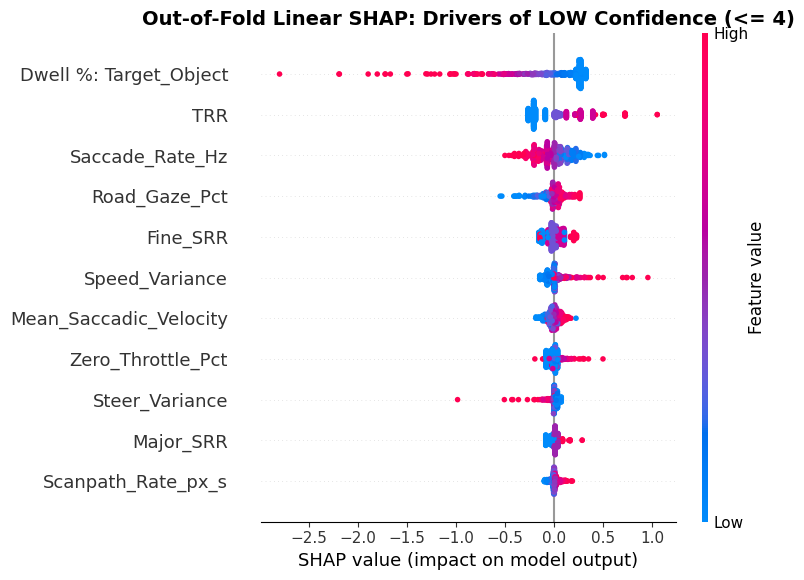

In [5]:
# ==========================================
# PART B (cont.), FINAL MODEL, TRAIN-ONLY THRESHOLD, OOF COEFFICIENTS + LINEAR SHAP
# ==========================================
gss = GroupShuffleSplit(1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(gss.split(X, y, groups))
X_tr, X_te, y_tr, y_te = X.iloc[tr_idx], X.iloc[te_idx], y.iloc[tr_idx], y.iloc[te_idx]
g_tr = groups.iloc[tr_idx]
final_model = make_model(); final_model.fit(X_tr, y_tr)

oof_tr = cross_val_predict(make_model(), X_tr, y_tr, groups=g_tr,
                           cv=GroupKFold(4), method='predict_proba')[:, 1]
pr_t, rc_t, th_t = precision_recall_curve(y_tr, oof_tr)
with np.errstate(invalid='ignore', divide='ignore'):
    den = pr_t[:-1] + rc_t[:-1]; f1_t = np.where(den == 0, 0, 2 * pr_t[:-1] * rc_t[:-1] / den)
BEST_THRESHOLD = float(th_t[int(np.argmax(f1_t))])
print(f"Train-derived F1-optimal threshold: {BEST_THRESHOLD:.4f}")

# --- OOF standardized coefficients + linear SHAP across folds ---
# Features are standardized inside the pipeline, so logreg coef_ ARE standardized
# coefficients (effect per 1 SD). Linear SHAP_ij = coef_j * (x_scaled_ij - mean_train_j).
coef_folds, oof_sv, oof_X = [], [], []
for tr, te in outer_cv.split(X, y, groups):
    if y.iloc[tr].nunique() < 2:
        continue
    mdl = make_model(); mdl.fit(X.iloc[tr], y.iloc[tr])
    lr = mdl.named_steps['m']; coef = lr.coef_[0]
    coef_folds.append(coef)
    Xtr_s = mdl[:-1].transform(X.iloc[tr]); Xte_s = mdl[:-1].transform(X.iloc[te])
    oof_sv.append((Xte_s - Xtr_s.mean(axis=0)) * coef)      # exact linear SHAP (log-odds)
    oof_X.append(X.iloc[te])
coef_folds = np.array(coef_folds)
shap_oof = np.vstack(oof_sv); X_oof = pd.concat(oof_X); y_oof = y.loc[X_oof.index]

mean_coef = coef_folds.mean(axis=0)
sign_consistent = [f"{int(np.mean(np.sign(coef_folds[:, j]) == np.sign(mean_coef[j])) * 100)}%"
                   for j in range(len(feature_cols))]
coef_tab = pd.DataFrame({'Feature': [clean(c) for c in feature_cols],
                         'Std_Coef': mean_coef, 'Odds_Ratio_per_SD': np.exp(mean_coef),
                         'Sign_stable': sign_consistent})
coef_tab = coef_tab.reindex(coef_tab['Std_Coef'].abs().sort_values(ascending=False).index)
print("\n--- STANDARDIZED LOGISTIC COEFFICIENTS (drivers of LOW confidence) ---")
print("  +coef / OR>1 => higher feature -> higher odds of an UNSURE response\n")
print(coef_tab.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

# --- Linear-SHAP beeswarm (for visual comparison with the other notebooks) ---
Xc = X_oof.copy(); Xc.columns = [clean(c) for c in feature_cols]
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_oof, Xc, show=False)
plt.title("Out-of-Fold Linear SHAP: Drivers of LOW Confidence (<= %d)" % LOW_CONF_CUT,
          fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show(); plt.close()


OOF PR-AUC = 0.365  95% CI [0.280, 0.466]  (chance 0.298; lift 1.2x)
OOF ROC-AUC = 0.604


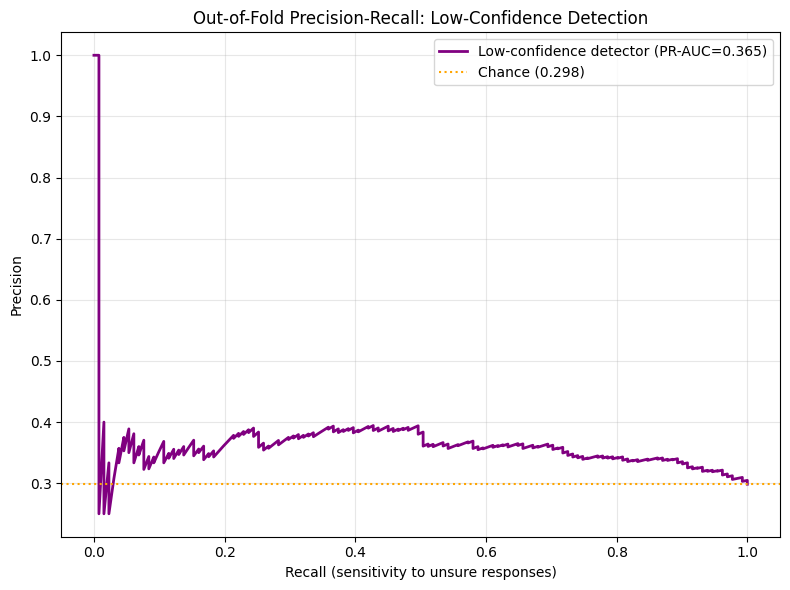


[secondary, illustrative] Holdout n=96 (37 unsure): ROC-AUC=0.547  PR-AUC=0.445
  Positive class (unsure) at pre-committed threshold 0.349: recall=0.86  precision=0.42  F1=0.57
Threshold sensitivity (low-confidence cut):
  conf<=3: pos=85 (19%)  ROC=0.676  PR=0.311 (chance 0.19)


  conf<=4: pos=131 (30%)  ROC=0.604  PR=0.365 (chance 0.30)
  conf<=5: pos=191 (44%)  ROC=0.588  PR=0.478 (chance 0.44)


In [6]:
# ==========================================
# PART B (cont.), OOF PRECISION-RECALL + HOLDOUT EVAL + THRESHOLD SENSITIVITY
# ==========================================
oofp = cross_val_predict(make_model(y), X, y, groups=groups, cv=GroupKFold(5),
                         method='predict_proba')[:, 1]
prec, rec, _ = precision_recall_curve(y, oofp); ap = average_precision_score(y, oofp); ch = y.mean()
rng = np.random.default_rng(42); pids = groups.unique(); gv = groups.values; boot = []
for _ in range(400):
    s = rng.choice(pids, len(pids), replace=True); idx = np.concatenate([np.where(gv == p)[0] for p in s])
    if y.iloc[idx].nunique() < 2: continue
    boot.append(average_precision_score(y.iloc[idx], oofp[idx]))
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"OOF PR-AUC = {ap:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  (chance {ch:.3f}; lift {ap/ch:.1f}x)")
print(f"OOF ROC-AUC = {roc_auc_score(y, oofp):.3f}")

plt.figure(figsize=(8, 6))
plt.plot(rec, prec, color='purple', lw=2, label=f'Low-confidence detector (PR-AUC={ap:.3f})')
plt.axhline(ch, color='orange', ls=':', label=f'Chance ({ch:.3f})')
plt.xlabel('Recall (sensitivity to unsure responses)'); plt.ylabel('Precision')
plt.title('Out-of-Fold Precision-Recall: Low-Confidence Detection')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show(); plt.close()

# SECONDARY CHECK: single 20% holdout (illustrative only; small + noisy).
# The REPORTED metric is the out-of-fold PR-AUC above. Accuracy/macro-F1 are
# omitted (misleading under imbalance); F1 is one reference point, not the target.
from sklearn.metrics import precision_score as _ps, recall_score as _rs, f1_score as _fs
yp = final_model.predict_proba(X_te)[:, 1]; yo = (yp >= BEST_THRESHOLD).astype(int)
print(f"\n[secondary, illustrative] Holdout n={len(y_te)} ({int(y_te.sum())} unsure): "
      f"ROC-AUC={roc_auc_score(y_te, yp):.3f}  PR-AUC={average_precision_score(y_te, yp):.3f}")
print(f"  Positive class (unsure) at pre-committed threshold {BEST_THRESHOLD:.3f}: "
      f"recall={_rs(y_te, yo, zero_division=0):.2f}  precision={_ps(y_te, yo, zero_division=0):.2f}  "
      f"F1={_fs(y_te, yo, zero_division=0):.2f}")

# threshold sensitivity (<=4 vs <=5)
print("Threshold sensitivity (low-confidence cut):")
for cut in [3, 4, 5]:
    yy = (conf <= cut).astype(int)
    if yy.sum() < 10: continue
    op = cross_val_predict(make_model(yy), X, yy, groups=groups, cv=GroupKFold(5), method='predict_proba')[:, 1]
    print(f"  conf<={cut}: pos={int(yy.sum())} ({yy.mean():.0%})  ROC={roc_auc_score(yy, op):.3f}  "
          f"PR={average_precision_score(yy, op):.3f} (chance {yy.mean():.2f})")


PART C: METACOGNITIVE CALIBRATION
Accuracy by reported confidence level:
      count  mean
conf             
1.0      48  0.10
2.0      25  0.60
3.0      27  0.63
4.0      58  0.84
5.0      81  0.84
6.0     121  0.94
7.0     299  0.96

Confidence->correctness AUC: all=0.843 | excluding Speed=0.829
  (0.5 = confidence unrelated to correctness; >0.5 = higher confidence -> more often correct)

Relative confidence (vs own baseline): mean on CORRECT = +0.400, on INCORRECT = -2.137

OVERCONFIDENT errors (confidence>=6 AND incorrect): 19 (4.5% of high-confidence responses)
UNDERCONFIDENT hits (confidence<=4 AND correct): 86 (54.4% of low-confidence responses)


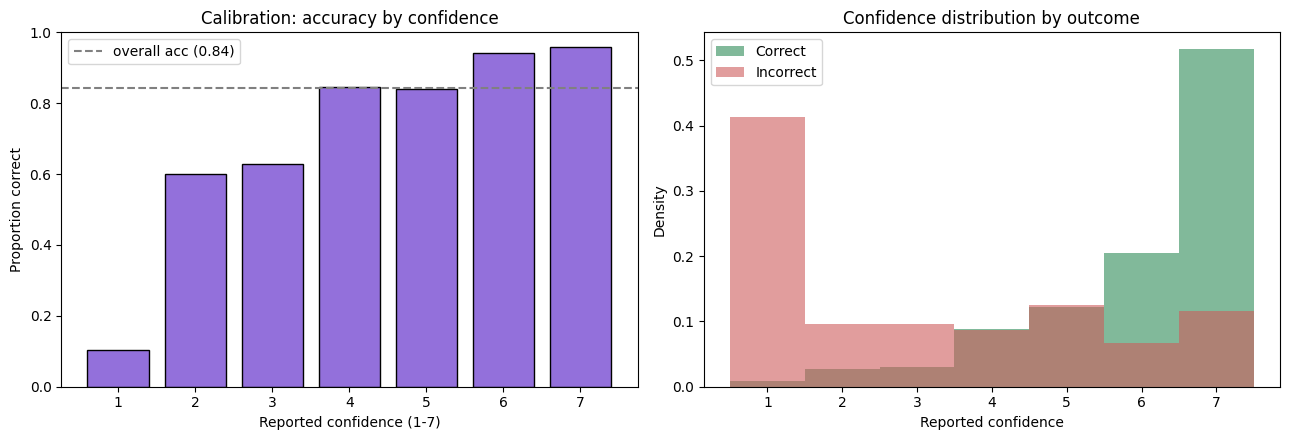

In [7]:
# ==========================================
# PART C: CALIBRATION: does confidence track actual correctness?
# ==========================================
print("="*70 + "\nPART C: METACOGNITIVE CALIBRATION\n" + "="*70)
# Part C (calibration) is reported TASK-WIDE (all query types): its central result
# is the cross-query-type contrast (Speed has near-constant accuracy).
acc = df_pooled['Target_Accuracy'].astype(int)          # 1 = correct
confP = df_pooled['Target_Confidence'].astype(float)
correct = acc.values

# 1) Accuracy by confidence level (calibration curve)
cal = pd.DataFrame({'conf': confP.values, 'correct': correct})
tab = cal.groupby('conf')['correct'].agg(['count', 'mean'])
print("Accuracy by reported confidence level:")
print(tab.to_string(float_format=lambda x: f"{x:.2f}"))

# 2) Resolution: does confidence discriminate correct vs incorrect? (AUC of confidence -> correctness)
auc_all = roc_auc_score(correct, confP.values)
ns = df_pooled['Question_Type'].str.lower() != 'speed'    # exclude near-constant-accuracy speed queries
auc_ns = roc_auc_score(correct[ns.values], confP.values[ns.values])
print(f"\nConfidence->correctness AUC: all={auc_all:.3f} | excluding Speed={auc_ns:.3f}")
print("  (0.5 = confidence unrelated to correctness; >0.5 = higher confidence -> more often correct)")

# 3) Within-person resolution using RELATIVE confidence (deviation from own mean)
rel_conf = confP.values - pd.Series(confP.values).groupby(df_pooled['Participant_ID'].values).transform('mean').values
print(f"\nRelative confidence (vs own baseline): mean on CORRECT = {rel_conf[correct==1].mean():+.3f}, "
      f"on INCORRECT = {rel_conf[correct==0].mean():+.3f}")

# 4) Overconfidence: high confidence (>=6) but WRONG
high = confP.values >= 6
over = int(((high) & (correct == 0)).sum())
print(f"\nOVERCONFIDENT errors (confidence>=6 AND incorrect): {over} "
      f"({over/max(high.sum(),1):.1%} of high-confidence responses)")
under = int(((confP.values <= LOW_CONF_CUT) & (correct == 1)).sum())
print(f"UNDERCONFIDENT hits (confidence<={LOW_CONF_CUT} AND correct): {under} "
      f"({under/max((confP.values<=LOW_CONF_CUT).sum(),1):.1%} of low-confidence responses)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(tab.index, tab['mean'], color='mediumpurple', edgecolor='black')
ax[0].set_xlabel('Reported confidence (1-7)'); ax[0].set_ylabel('Proportion correct')
ax[0].set_title('Calibration: accuracy by confidence'); ax[0].set_ylim(0, 1)
ax[0].axhline(correct.mean(), color='gray', ls='--', label=f'overall acc ({correct.mean():.2f})'); ax[0].legend()
bins = np.arange(1, 9) - 0.5
ax[1].hist(confP.values[correct == 1], bins=bins, alpha=0.6, label='Correct', color='seagreen', density=True)
ax[1].hist(confP.values[correct == 0], bins=bins, alpha=0.6, label='Incorrect', color='indianred', density=True)
ax[1].set_xlabel('Reported confidence'); ax[1].set_ylabel('Density')
ax[1].set_title('Confidence distribution by outcome'); ax[1].legend()
plt.tight_layout(); plt.show(); plt.close()


In [8]:
# ==========================================
# PART C (cont.), SUMMARY
# ==========================================
print("CONFIDENCE ANALYSIS SUMMARY")
print("-"*60)
print("A) Continuous confidence: NOT predictable from pre-query behaviour (R2 ~ 0,")
print("   ~83% within-person variance) -> decoupled from accuracy/delayed-response precursors.")
print(f"B) Low-confidence (<= {LOW_CONF_CUT}) flag: weakly detectable (see OOF ROC/PR above);")
print("   report PR-AUC + CI; lead with it being modest, exploratory.")
print("C) Calibration: see confidence->correctness AUC and overconfident-error count;")
print("   relative confidence is higher on correct than incorrect responses if metacognition")
print("   has resolution. Overconfident errors (high confidence + wrong) are the SA hazard.")


CONFIDENCE ANALYSIS SUMMARY
------------------------------------------------------------
A) Continuous confidence: NOT predictable from pre-query behaviour (R2 ~ 0,
   ~83% within-person variance) -> decoupled from accuracy/delayed-response precursors.
B) Low-confidence (<= 4) flag: weakly detectable (see OOF ROC/PR above);
   report PR-AUC + CI; lead with it being modest, exploratory.
C) Calibration: see confidence->correctness AUC and overconfident-error count;
   relative confidence is higher on correct than incorrect responses if metacognition
   has resolution. Overconfident errors (high confidence + wrong) are the SA hazard.


In [9]:
# ==========================================
# OVERT-LAPSE ANALYSIS: Before_Hazard_Encountered (ran over boundary/cones)
# ==========================================
# This is an OVERT control LAPSE (a symptom of already-degraded SA), not an
# unobtrusive antecedent -> EXCLUDED from the predictive models above. Reported
# here descriptively, and recommended as a RULE-BASED OVERRIDE in a live detector.
hz = df_pooled['Before_Hazard_Encountered'] > 0   # task-wide overt-lapse descriptive
inc = 1 - df_pooled['Target_Accuracy']; delayed = (df_pooled['Target_Latency'] >= 3.5).astype(int)
uns = (df_pooled['Target_Confidence'] <= LOW_CONF_CUT).astype(int)
print(f"Pre-query overt lapse present in {int(hz.sum())}/{len(df_pooled)} trials ({hz.mean():.0%}).")
print(f"\n{'Outcome':<12}{'lapse':>9}{'no-lapse':>10}{'risk ratio':>12}")
for nm, o in [('incorrect', inc), ('delayed', delayed), ('unsure', uns)]:
    r1, r0 = o[hz].mean(), o[~hz].mean()
    print(f"{nm:<12}{r1:>9.2f}{r0:>10.2f}{r1/max(r0,1e-9):>11.1f}x")
print("\nDEPLOYMENT NOTE: a rare high-precision lapse belongs in a RULE OVERRIDE, not")
print("as a soft model feature (a 4%-prevalence event gets diluted by a balanced model):")
print("   flag_low_SA = (model_probability >= threshold) OR (ran_over_cones)")


Pre-query overt lapse present in 27/659 trials (4%).

Outcome         lapse  no-lapse  risk ratio
incorrect        0.30      0.15        2.0x
delayed          0.26      0.10        2.6x
unsure           0.48      0.23        2.1x

DEPLOYMENT NOTE: a rare high-precision lapse belongs in a RULE OVERRIDE, not
as a soft model feature (a 4%-prevalence event gets diluted by a balanced model):
   flag_low_SA = (model_probability >= threshold) OR (ran_over_cones)
